# MISION: Preparar el Quirofano

**Problema:** Datos mixtos — numericos + categoricos + nulos. El modelo no entiende "Male" ni "Private". Necesitamos traducirlo todo a numeros.

---

### Retos
1. **Nulos:** BMI tiene 201 valores faltantes
2. **Categoricas:** 5 columnas con texto que los algoritmos no digieren
3. **Desbalance extremo:** 95.1% vs 4.9% — el split debe ser estratificado
4. **Escalas distintas:** edad (0-82), glucosa (55-272), BMI (10-97) — necesitan normalizacion

**Objetivo:** Pasar de 11 columnas crudas a una matriz de features limpia, codificada y escalada, lista para alimentar modelos.

## 1. Imports y Configuracion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# Estilo y colores
plt.style.use('seaborn-v0_8-whitegrid')
NO_STROKE = '#2ecc71'
STROKE = '#e74c3c'

# Rutas
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data", "heart_attack")
processed_dir = os.path.join(data_dir, "processed")
os.makedirs(processed_dir, exist_ok=True)

print(f"Datos: {data_dir}")
print(f"Salida: {processed_dir}")

Datos: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/heart_attack
Salida: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/heart_attack/processed


## 2. Carga de Datos (autocontenido)

In [2]:
df = pd.read_csv(os.path.join(data_dir, "healthcare-dataset-stroke-data.csv"))
df.drop(columns=['id'], inplace=True)
print(f"Dimensiones originales: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print(f"\nNulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dimensiones originales: (5110, 11)
Columnas: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Nulos por columna:
bmi    201
dtype: int64


## 3. Imputacion de BMI por Grupo de Edad

BMI varia con la edad. Imputar con la mediana global seria burdo. Mejor: mediana por grupo etario.

In [3]:
# Definir bins de edad
age_bins = [0, 18, 40, 60, 100]
age_labels = ['0-18', '18-40', '40-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Mediana de BMI por grupo
bmi_medians = df.groupby('age_group')['bmi'].median()
print("Mediana de BMI por grupo de edad:")
print(bmi_medians)
print(f"\nNulos en BMI antes: {df['bmi'].isnull().sum()}")

Mediana de BMI por grupo de edad:
age_group
0-18     19.9
18-40    27.7
40-60    30.3
60+      29.2
Name: bmi, dtype: float64

Nulos en BMI antes: 201


In [4]:
# Guardar distribucion original para comparar
bmi_before = df['bmi'].copy()

# Imputar
for group in age_labels:
    mask = (df['age_group'] == group) & (df['bmi'].isnull())
    df.loc[mask, 'bmi'] = bmi_medians[group]

print(f"Nulos en BMI despues: {df['bmi'].isnull().sum()}")

Nulos en BMI despues: 0


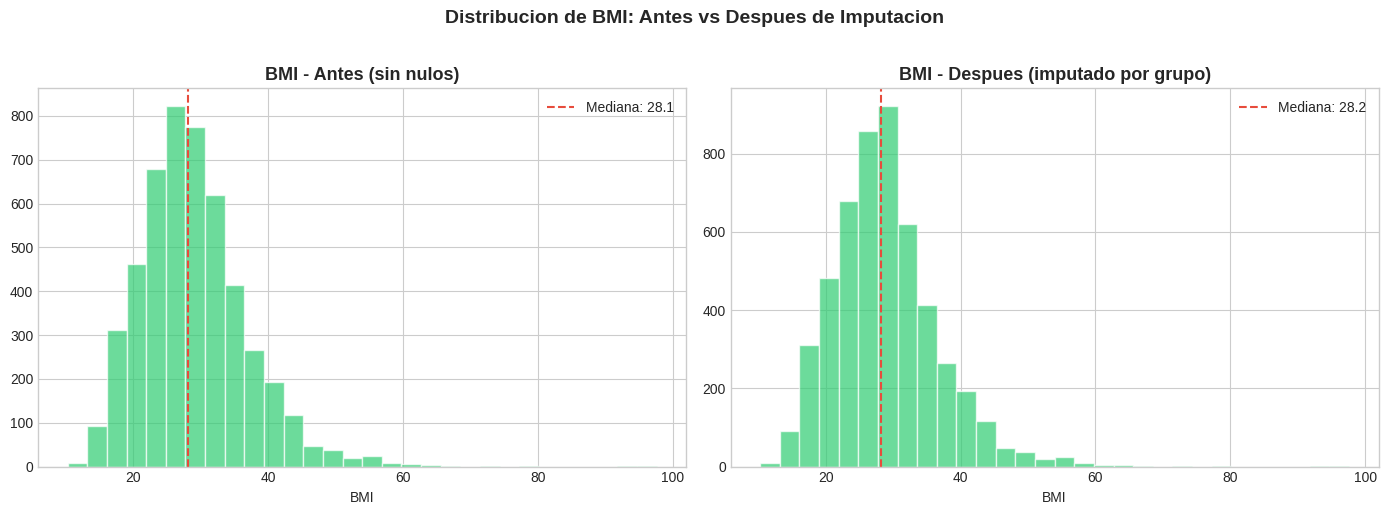

La distribucion se mantiene practicamente igual. Imputacion conservadora.


In [5]:
# Comparar distribuciones antes/despues
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(bmi_before.dropna(), bins=30, color=NO_STROKE, alpha=0.7, edgecolor='white')
axes[0].set_title('BMI - Antes (sin nulos)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].axvline(bmi_before.median(), color=STROKE, linestyle='--', label=f'Mediana: {bmi_before.median():.1f}')
axes[0].legend()

axes[1].hist(df['bmi'], bins=30, color=NO_STROKE, alpha=0.7, edgecolor='white')
axes[1].set_title('BMI - Despues (imputado por grupo)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].axvline(df['bmi'].median(), color=STROKE, linestyle='--', label=f'Mediana: {df["bmi"].median():.1f}')
axes[1].legend()

plt.suptitle('Distribucion de BMI: Antes vs Despues de Imputacion', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("La distribucion se mantiene practicamente igual. Imputacion conservadora.")

In [6]:
# Eliminar columna auxiliar
df.drop(columns=['age_group'], inplace=True)

## 4. Smoking Status: "Unknown" se queda

"Unknown" no es un error — puede ser que no se pregunto, lo cual correlaciona con un perfil demografico distinto. Lo tratamos como categoria propia.

In [7]:
print("Distribucion de smoking_status:")
print(df['smoking_status'].value_counts())
print(f"\nTasa de stroke por smoking_status:")
print((df.groupby('smoking_status')['stroke'].mean() * 100).round(2).to_string())
print("\n'Unknown' tiene tasa de stroke distinta a las demas. Confirma que es informativo.")

Distribucion de smoking_status:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

Tasa de stroke por smoking_status:
smoking_status
Unknown            3.04
formerly smoked    7.91
never smoked       4.76
smokes             5.32

'Unknown' tiene tasa de stroke distinta a las demas. Confirma que es informativo.


## 5. Filtrar gender="Other"

Solo 1 caso. No aporta informacion estadistica y puede causar ruido.

In [8]:
print(f"Registros con gender='Other': {(df['gender'] == 'Other').sum()}")
df = df[df['gender'] != 'Other'].reset_index(drop=True)
print(f"Dimensiones tras filtro: {df.shape}")

Registros con gender='Other': 1
Dimensiones tras filtro: (5109, 11)


## 6. Codificacion de Variables Categoricas

Dos estrategias:
- **Binarias:** mapeo directo a 0/1
- **Multiclase:** One-Hot Encoding (drop_first para evitar colinealidad)

In [9]:
# Codificacion binaria
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['ever_married'] = df['ever_married'].map({'Yes': 1, 'No': 0})
df['Residence_type'] = df['Residence_type'].map({'Urban': 1, 'Rural': 0})

print("Codificacion binaria aplicada:")
print(f"  gender:         Male=1, Female=0")
print(f"  ever_married:   Yes=1, No=0")
print(f"  Residence_type: Urban=1, Rural=0")
print(f"\nVerificacion:")
print(df[['gender', 'ever_married', 'Residence_type']].describe())

Codificacion binaria aplicada:
  gender:         Male=1, Female=0
  ever_married:   Yes=1, No=0
  Residence_type: Urban=1, Rural=0

Verificacion:
            gender  ever_married  Residence_type
count  5109.000000   5109.000000     5109.000000
mean      0.413975      0.656293        0.508123
std       0.492592      0.474991        0.499983
min       0.000000      0.000000        0.000000
25%       0.000000      0.000000        0.000000
50%       0.000000      1.000000        1.000000
75%       1.000000      1.000000        1.000000
max       1.000000      1.000000        1.000000


In [10]:
# One-Hot Encoding para work_type y smoking_status
print(f"Categorias en work_type: {df['work_type'].unique()}")
print(f"Categorias en smoking_status: {df['smoking_status'].unique()}")

df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first=True, dtype=int)

print(f"\nColumnas tras One-Hot Encoding:")
print(list(df.columns))
print(f"\nDimensiones: {df.shape}")

Categorias en work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Categorias en smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']

Columnas tras One-Hot Encoding:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']

Dimensiones: (5109, 16)


## 7. Separacion de Features y Target

In [11]:
X = df.drop(columns=['stroke'])
y = df['stroke']

print(f"Features (X): {X.shape}")
print(f"Target (y):   {y.shape}")
print(f"\nColumnas de X:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col} ({X[col].dtype})")

Features (X): (5109, 15)
Target (y):   (5109,)

Columnas de X:
   1. gender (int64)
   2. age (float64)
   3. hypertension (int64)
   4. heart_disease (int64)
   5. ever_married (int64)
   6. Residence_type (int64)
   7. avg_glucose_level (float64)
   8. bmi (float64)
   9. work_type_Never_worked (int64)
  10. work_type_Private (int64)
  11. work_type_Self-employed (int64)
  12. work_type_children (int64)
  13. smoking_status_formerly smoked (int64)
  14. smoking_status_never smoked (int64)
  15. smoking_status_smokes (int64)


## 8. Train/Test Split (Estratificado)

Con solo 4.9% de positivos, un split aleatorio podria dejar el test set sin casos de stroke. **Stratify** garantiza la misma proporcion en ambos sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")
print(f"\nProporcion de stroke:")
print(f"  Train: {y_train.mean()*100:.2f}%")
print(f"  Test:  {y_test.mean()*100:.2f}%")
print(f"  Total: {y.mean()*100:.2f}%")
print("\nProporciones practicamente identicas. Stratify funciona.")

Train: 4087 muestras
Test:  1022 muestras

Proporcion de stroke:
  Train: 4.87%
  Test:  4.89%
  Total: 4.87%

Proporciones practicamente identicas. Stratify funciona.


## 9. Escalado con StandardScaler

Solo las columnas numericas continuas necesitan escalado. Las binarias y one-hot ya estan en rango adecuado.

**Regla de oro:** fit en train, transform en train Y test. Nunca fit en test.

In [13]:
numeric_to_scale = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()

# Fit SOLO en train
X_train[numeric_to_scale] = scaler.fit_transform(X_train[numeric_to_scale])
# Transform test con los parametros de train
X_test[numeric_to_scale] = scaler.transform(X_test[numeric_to_scale])

print("Parametros del scaler (aprendidos del train):")
for col, mean, std in zip(numeric_to_scale, scaler.mean_, scaler.scale_):
    print(f"  {col:<20} media={mean:.2f}  std={std:.2f}")

print(f"\nVerificacion en train (deben ser ~0 y ~1):")
print(X_train[numeric_to_scale].describe().loc[['mean', 'std']].round(4))

Parametros del scaler (aprendidos del train):
  age                  media=43.26  std=22.64
  avg_glucose_level    media=105.90  std=44.67
  bmi                  media=28.86  std=7.76

Verificacion en train (deben ser ~0 y ~1):
         age  avg_glucose_level     bmi
mean -0.0000             0.0000 -0.0000
std   1.0001             1.0001  1.0001


## 10. Matriz Final de Features

In [14]:
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nColumnas ({X_train.shape[1]} features):")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col:<35} dtype={X_train[col].dtype}")

print(f"\nPrimeras 5 filas de X_train:")
X_train.head()

X_train: (4087, 15)
X_test:  (1022, 15)

Columnas (15 features):
   1. gender                              dtype=int64
   2. age                                 dtype=float64
   3. hypertension                        dtype=int64
   4. heart_disease                       dtype=int64
   5. ever_married                        dtype=int64
   6. Residence_type                      dtype=int64
   7. avg_glucose_level                   dtype=float64
   8. bmi                                 dtype=float64
   9. work_type_Never_worked              dtype=int64
  10. work_type_Private                   dtype=int64
  11. work_type_Self-employed             dtype=int64
  12. work_type_children                  dtype=int64
  13. smoking_status_formerly smoked      dtype=int64
  14. smoking_status_never smoked         dtype=int64
  15. smoking_status_smokes               dtype=int64

Primeras 5 filas de X_train:


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
845,0,0.209397,0,0,1,1,-0.821221,0.546491,0,1,0,0,0,1,0
3744,0,-0.629845,0,0,0,1,-0.485884,-0.987752,0,1,0,0,0,1,0
4183,0,-0.364822,0,0,1,0,0.302317,-0.768574,0,1,0,0,0,1,0
3409,1,-0.232310,0,0,1,0,0.062342,0.494920,0,1,0,0,0,1,0
284,1,-1.292405,0,0,0,1,-0.527297,0.353099,0,0,0,0,0,0,0


In [15]:
X_train.describe().round(3)

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
count,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000,4087.000
mean,0.414,-0.000,0.095,0.057,0.660,0.503,0.000,-0.000,0.004,0.569,0.162,0.136,0.175,0.372,0.151
std,0.493,1.000,0.293,0.231,0.474,0.500,1.000,1.000,0.062,0.495,0.369,0.343,0.380,0.483,0.358
min,0.000,-1.907,0.000,0.000,0.000,0.000,-1.134,-2.393,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,-0.807,0.000,0.000,0.000,0.000,-0.637,-0.678,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.077,0.000,0.000,1.000,1.000,-0.314,-0.085,0.000,1.000,0.000,0.000,0.000,0.000,0.000
75%,1.000,0.784,0.000,0.000,1.000,1.000,0.182,0.508,0.000,1.000,0.000,0.000,0.000,1.000,0.000
max,1.000,1.711,1.000,1.000,1.000,1.000,3.713,8.862,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 11. Guardar en Parquet

In [16]:
X_train.to_parquet(os.path.join(processed_dir, 'X_train.parquet'), index=False)
X_test.to_parquet(os.path.join(processed_dir, 'X_test.parquet'), index=False)
y_train.to_frame().to_parquet(os.path.join(processed_dir, 'y_train.parquet'), index=False)
y_test.to_frame().to_parquet(os.path.join(processed_dir, 'y_test.parquet'), index=False)

print("Archivos guardados en:")
for f in ['X_train.parquet', 'X_test.parquet', 'y_train.parquet', 'y_test.parquet']:
    fpath = os.path.join(processed_dir, f)
    size = os.path.getsize(fpath) / 1024
    print(f"  {f:<20} ({size:.1f} KB)")

Archivos guardados en:
  X_train.parquet      (60.2 KB)
  X_test.parquet       (25.5 KB)
  y_train.parquet      (1.6 KB)
  y_test.parquet       (1.3 KB)


## 12. Resumen del Pipeline

| Paso | Accion | Resultado |
|------|--------|-----------|
| 1 | Drop `id` | 12 -> 11 columnas |
| 2 | Imputar BMI por grupo de edad | 201 nulos eliminados |
| 3 | Mantener smoking_status "Unknown" | Categoria informativa |
| 4 | Filtrar gender="Other" | 5,110 -> 5,109 filas |
| 5 | Codificacion binaria | gender, ever_married, Residence_type -> 0/1 |
| 6 | One-Hot Encoding | work_type (4 dummies), smoking_status (3 dummies) |
| 7 | Train/Test split estratificado | 80/20, misma proporcion de stroke |
| 8 | StandardScaler | age, avg_glucose_level, bmi normalizados |
| 9 | Guardar en Parquet | 4 archivos listos para modelado |

**Resultado:** De 11 features originales a ~15 features codificadas, limpias y escaladas.

**Siguiente paso:** Modelado con manejo de desbalance (SMOTE, class_weight, threshold tuning).